In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from FNO_vmapped import *
import pybamm
import flax
import functools
import optax

In [2]:
anode_file = "trained_models/anode_GRF__2025-03-31_00-38-52.msgpack"
cathode_file = "trained_models/cathode_GRF__2025-03-31_01-26-36.msgpack"

train_data = np.load("data/spm/for_soc/test/GRF_2200.npz")
test_data = np.load("data/spm/for_soc/test/GRF_2200.npz")

In [3]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn_anode = jnp.array(train_data["target_concentration_anode"])
test_cn_anode = jnp.array(test_data["target_concentration_anode"])

train_c0_anode = jnp.array(train_data["initial_concentration_anode"])
test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

train_cn_cathode = jnp.array(train_data["target_concentration_cathode"])
test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

train_c0_cathode = jnp.array(train_data["initial_concentration_cathode"])
test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [4]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [ ]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
hidden_channels = 64
output_channels = 1

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar

# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
#input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
anode = model.apply(params, input_tensor)
cathode = model.apply(params, input_tensor)
print("Output shape:", anode.shape)  # should be (1,24,85,1)
print("Output shape:", cathode.shape)

In [ ]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = jnp.zeros((num_samples, H, W, 4))
    Y = jnp.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)

    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = jnp.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = jnp.tile(c0_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = jnp.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = jnp.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)

    # Stack channels: (num_samples,24,85,4)
    X = jnp.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = jnp.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [ ]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

parameter_name = "Chen2020"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [ ]:
socs = [0. + i*0.01 for i in range(101)]
c0s_anode = []
c0s_cathode = []
spm = pybamm.lithium_ion.SPM()
spm.events = []
sim = pybamm.Simulation(spm, parameter_values=params_bat)
for soc in socs:
    sol = sim.solve(initial_soc=soc, t_eval = t)
    c0s_anode.append(sol["Negative particle concentration"].entries[0, 0, 0])
    c0s_cathode.append(sol["Positive particle concentration"].entries[0, 0, 0])

coeff_anode = np.polyfit(c0s_anode, socs, 1)
coeff_cathode = np.polyfit(c0s_cathode, socs, 1)

soc_from_c0_anode = lambda x: jnp.polyval(coeff_anode, x)
soc_from_c0_cathode = lambda x: jnp.polyval(coeff_cathode, x)

In [ ]:
@jax.jit
def soc_to_c0(soc):
    """
    Given a state-of-charge (soc) value (scalar or array), compute the corresponding
    anode and cathode initial concentrations based on the linear fits.
    
    Returns:
        A tuple (c0_anode, c0_cathode)
    """
    c0_anode = (soc - coeff_anode[1]) / coeff_anode[0]
    c0_cathode = (soc - coeff_cathode[1]) / coeff_cathode[0]
    
    c0_anode = jnp.full((20,), c0_anode)
    c0_cathode = jnp.full((20,), c0_cathode)

    return c0_anode, c0_cathode

In [ ]:
c0s_anode = np.array(c0s_anode)
c0s_cathode = np.array(c0s_cathode)
total_li = np.mean(c0s_cathode*np.pi*4/3*Rca**3*cs_max_c + c0s_anode*np.pi*4/3*Ran**3*cs_max_a)

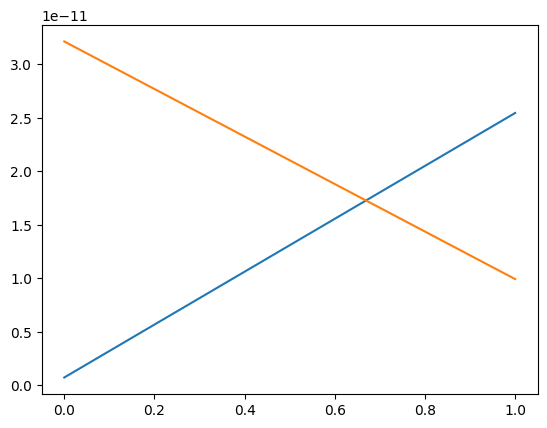

In [ ]:
plt.plot(socs, c0s_anode*jnp.pi*4/3*Ran**3*cs_max_a)
plt.plot(socs, c0s_cathode*jnp.pi*4/3*Rca**3*cs_max_c)
#plt.plot(socs, c0s_cathode*jnp.pi*4/3*Rca**3*cs_max_c + c0s_anode*jnp.pi*4/3*Ran**3*cs_max_a)

In [ ]:
params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [ ]:
train_idx = np.random.randint(2, 88000)
test_idx = np.random.randint(2, 8800)

In [ ]:
def get_dummy_measurement(I, cn_anode, cn_cathode, noise = 0, max_retries = 1000, idx = None):

    for _ in range(max_retries):

        if np.isnan(idx):
            test_idx = np.random.randint(0, 8800)
        else:
            test_idx = idx
            
        I_test = I[test_idx]
        cn_anode_test = cn_anode[test_idx]
        cn_cathode_test = cn_cathode[test_idx]

        _, V_true = functions.post_proc(params_bat, I_test, 0, cn_anode_test[-1,:], 0, cn_cathode_test[-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
        
        if jnp.isnan(V_true).any():
            continue
        else:
            return V_true + noise, test_idx
    
    raise ValueError("Could not produce a NaN-free measurement after {} retries.".format(max_retries))

In [ ]:
def U_OCP_an(sto):
    u_eq = (
        1.9793 * jnp.exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * jnp.tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * jnp.tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * jnp.tanh(30.4444 * (sto - 0.6103))
    )

    return u_eq

def U_OCP_ca(sto):
    u_eq = (
        -0.8090 * sto
        + 4.4875
        - 0.0428 * jnp.tanh(18.5138 * (sto - 0.5542))
        - 17.7326 * jnp.tanh(15.7890 * (sto - 0.3117))
        + 17.5842 * jnp.tanh(15.9308 * (sto - 0.3120))
    )

    return u_eq


    return u_eq


In [ ]:
# U_OCP_an = params_bat["Negative electrode OCP [V]"]
# U_OCP_ca = params_bat["Positive electrode OCP [V]"]
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [ ]:
def in_arcsinh(I, R, epsilon, L, A):

    x = I * R / (3 * epsilon * L * A)

    return x

In [ ]:

t_lin = t/t_max
R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))

In [ ]:
from scipy.optimize import minimize

In [ ]:
def preprocess_candidates(I_array, c0_array):
    """
    Convert a single (or batch of) current and c0 arrays into
    padded 2D channels for the FNO: shape (B, 24, 85, 4).
    
    Parameters
    ----------
    I_array : jnp.ndarray
        If shape is (75,) => a single sample. Or (B,75) => batch.
    c0_array : jnp.ndarray
        If shape is (20,) => a single sample. Or (B,20) => batch.
    
    Returns
    -------
    X : jnp.ndarray
        FNO input, shape (B, 24, 85, 4).
        Where channels are: [I_2D, c0_2D, R_padded, T_padded].
    """
    # # 1) Ensure we have a batch dimension. If user passes shape (75,), add batch=1
    # if I_array.ndim == 1:
    #     I_array = I_array[None, :]   # shape (1,75)
    # if c0_array.ndim == 1:
    #     c0_array = c0_array[None, :] # shape (1,20)
    
    # B = I_array.shape[0]  # batch size
    
    # 2) Pad along t-axis => shape (B, 75+10) = (B,85)
    I_padded = jnp.pad(I_array, (padding_t, padding_t))  # (B,85)
    # 3) Pad along r-axis => shape (B, 20+4) = (B,24)
    c0_padded = jnp.pad(c0_array, (padding_r, padding_r)) # (B,24)

    # 4) Broadcast to (B, 24,85)
    I_2D = jnp.tile(I_padded[None, :], (H, 1))       # shape (B,24,85)
    c0_2D = jnp.tile(c0_padded[:, None], (1, W))     # shape (B,24,85)
    
    # 5) Broadcast R_padded, T_padded => shape (B,24,85)
    #    They are constant, so just replicate along batch dimension
    
    # R_3D = jnp.tile(R[None, ...], (B, 1, 1))  # (B,24,85)
    # T_3D = jnp.tile(T[None, ...], (B, 1, 1))  # (B,24,85)

    # 6) Stack channels => shape (B, 24,85,4)
    X = jnp.stack([I_2D, c0_2D, R, T], axis=-1)
    
    # print(X.shape)

    return X

In [ ]:
def postprocess_candidates(c_pred: jnp.ndarray,) -> jnp.ndarray:
    eps = 1e-6
    """
    Post-process FNO output for a single electrode (anode or cathode).
    1. Removes radial/time padding (2 in r, 5 in t).
    2. Extracts the last radial index (surface).
    
    Parameters
    ----------
    c_pred : jnp.ndarray
        FNO predictions of shape (B, 24, 85, 1) for a batch size B (or B=1).

    Returns
    -------
    jnp.ndarray
        Surface concentration at the outer radial index, shape (B, W_orig).
    """
    
    # Unpad the radial and time dimensions: shape (B, 20, 75)
    c_unpadded = c_pred[
        padding_r : padding_r + H_orig,
        padding_t : padding_t + W_orig,
        0
    ]

    # Take the last radial index => surface concentration, shape (B, 75)
    c_surface = c_unpadded[-1, :]


    #These values can be negative. Because they are going to be part in a square root we filter out negative values in order to avoid nans
    # c_surface = jnp.maximum(c_surface, eps)
    c_surface = jnp.clip(c_surface,eps,1-eps)

    return c_surface


In [ ]:
#@functools.partial(jax.vmap, in_axes=(0, 0, None), out_axes=0)
def fno_predict_voltage(c0_anode, c0_cathode, current):
# def post_proc(params, I_c, c_pred_an, c_true_an, c_pred_ca, c_true_ca, Ran, Rca, epsan, epsca, Lan, Lca, A):

    X_anode = preprocess_candidates(current,c0_anode)
    X_cathode = preprocess_candidates(current,c0_cathode)

    cn_anode = model.apply(params_anode,X_anode)
    cn_cathode = model.apply(params_cathode,X_cathode)
    
    cn_anode_surf = postprocess_candidates(cn_anode)
    cn_cathode_surf = postprocess_candidates(cn_cathode)

    j_anode = cn_anode_surf**0.5 * (1-cn_anode_surf)**0.5
    j_cathode = cn_cathode_surf**0.5 * (1-cn_cathode_surf)**0.5

    xan = in_arcsinh(-current, Ran, epsan, Lan, A)
    xca = in_arcsinh(-current, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

In [ ]:
#V_pred = fno_predict_voltage(test_c0_anode[:1000], test_c0_cathode[:1000], test_I[:1000])

In [ ]:
######Jetzt gehts los######

batch_size = 100

V_meas, test_idx = get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise = 0, idx = 0)


In [ ]:
target_current = test_I[test_idx]

In [ ]:
# def reinit_guesses(c0_batch, mask_nans, key):
#     """
#     Re-init only those rows that produced NaNs.
#     mask_nans is shape (B,) boolean.
#     c0_batch is shape (B,num_r).
#     """
#     B, num_r = c0_batch.shape
#     # We'll make random guesses in [0,1] for each row that needs re-init
#     new_c0 = jax.random.uniform(key, shape=(mask_nans.sum(), 20))
#     # c0_batch.at[mask_nans, :].set(...) sets only the True rows
#     c0_batch = c0_batch.at[mask_nans, :].set(new_c0)
#     return c0_batch

In [ ]:
@jax.jit
# @functools.partial(jax.vmap, in_axes=(0, 0, None, None), out_axes=0)
def objective_fn_forward(c0_anode, c0_cathode, current, V_meas):
    # Predict shape (1,75)
    # current_batch = jnp.tile(current[None,...], (batch_size, 1))
    # V_meas_batch = jnp.tile(V_meas[None,...], (batch_size, 1))

    V_pred = fno_predict_voltage(c0_anode, c0_cathode, current)
    # V_pred = jax.vmap(fno_predict_voltage(c0_anode, c0_cathode, current), in_axes=(0, 0, None, None))
    # mask_nans = jnp.isnan(V_pred).any(axis=1)

    # if jnp.any(mask_nans):
    #     c0_batch = reinit_guesses(c0_batch, mask_nans, key)
    conservation_loss = (total_li - jnp.mean(c0_anode*jnp.pi*4/3*Ran**3*cs_max_a + c0_cathode*jnp.pi*4/3*Rca**3*cs_max_c)* 1e9)**2

    residuals = V_pred - V_meas  # shape (75,)
    return jnp.mean(residuals**2) + conservation_loss #V_pred, V_meas_batch #jnp.mean(residuals**2)

In [ ]:
def soc_search(
    c0_an_init, c0_ca_init, current, V_meas,
    threshold=1e-4,
    max_iterations=20
):
    """
    Repeatedly:
      1) fno_predict_voltage
      2) check which rows produce NaNs -> reinit them
      3) check which rows are "good fit" -> done if any row is good
    If you want to keep searching until a row is good, we can break early.
    """
    c0_anode = c0_an_init
    c0_cathode = c0_ca_init

    for it in range(max_iterations):
        # 1) Forward pass
        # rmse_each = fno_predict_voltage(c0_an_init, c0_ca_init, current_batch)  # shape (B,75)

        # # 2) Identify NaNs
        # mask_nans = jnp.isnan(rmse_each).any(axis=1)

        # # Reinit the ones with NaNs
        # if jnp.any(mask_nans):
        #     c0_anode, keys_batch = reinit_guesses(c0_anode, mask_nans, keys_batch)
        #     c0_cathode, keys_batch = reinit_guesses(c0_cathode, mask_nans, keys_batch)

        # Check for "good fit" below threshold

        rmse, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0,1))(c0_anode, c0_cathode, current, V_meas)

        if rmse < threshold:
            return c0_anode, c0_cathode
        
        c0_anode = c0_anode - learning_rate * grad_an
        c0_cathode = c0_cathode - learning_rate * grad_ca

    return 0.

In [ ]:
losses = []
def catch_loss(loss):
    losses.append(loss)

In [ ]:
# @jax.jit
# def soc_search_jax(c0_an_init, c0_ca_init, current, V_meas,
#                    threshold=1e-4,
#                    max_iterations=1000,
#                    learning_rate=1e-3):
#     """
#     Fully jittable soc search using jax.lax.while_loop.
    
#     c0_an_init and c0_ca_init are the initial conditions for one sample.
#     current and V_meas are constants for that sample.
#     """
#     # Initialize iteration counter and loss; mark converged flags per sample.
#     # Using a tuple to hold our state:
#     #   state = (c0_an, c0_ca, iteration, loss, converged)
#     init_state = (c0_an_init, c0_ca_init, 0, jnp.inf, False)

#     def cond_fn(state):
#         _, _, it, loss, converged = state
#         # Continue if not converged and iteration < max_iterations.
#         return jnp.logical_and(loss > threshold, it < max_iterations)

#     def body_fn(state):
#         c0_an, c0_ca, it, loss, converged = state
#         # Compute loss and gradients w.r.t. both initial conditions.
#         loss, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0, 1))(
#             c0_an, c0_ca, current, V_meas
#         )
#         # jax.debug.callback(print,loss)
#         # Update only if not converged. (This simulates early stopping per sample)
#         c0_an_new = jax.lax.select(converged, c0_an, c0_an - learning_rate * grad_an)
#         c0_ca_new = jax.lax.select(converged, c0_ca, c0_ca - learning_rate * grad_ca)
#         # Determine if the current sample is converged.
#         converged_new = loss < threshold
#         return (c0_an_new, c0_ca_new, it + 1, loss, converged_new)

#     final_state = jax.lax.while_loop(cond_fn, body_fn, init_state)
#     # Unpack final state
#     c0_an_final, c0_ca_final, it, loss, converged = final_state
#     return c0_an_final, c0_ca_final, loss

In [ ]:
# import jax
# import jax.numpy as jnp
# import optax

# Define the optimizer outside the inner function so it can be reused.
adam_optimizer = optax.adam(learning_rate=1e-3)

@jax.jit
def soc_search_jax_inner(state, current, V_meas):
    """
    The inner optimization loop.
    
    The state tuple is:
      (c0_an, c0_ca, opt_state_an, opt_state_ca, iteration, loss, converged)
    """
    def cond_fn(state):
        _, _, _, _, it, loss, converged = state
        return jnp.logical_and(loss > 1e-4, it < 1000)

    def body_fn(state):
        c0_an, c0_ca, opt_state_an, opt_state_ca, it, loss, converged = state

        # Compute loss and gradients for both parameters.
        loss, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0, 1))(
            c0_an, c0_ca, current, V_meas
        )
        # conservation_loss = (total_li - jnp.mean(c0_ca*jnp.pi*4/3*Rca**3*cs_max_c + c0_an*jnp.pi*4/3*Ran**3*cs_max_a))**2
        
        # Get Adam updates using optax.
        updates_an, new_opt_state_an = adam_optimizer.update(grad_an, opt_state_an, c0_an)
        updates_ca, new_opt_state_ca = adam_optimizer.update(grad_ca, opt_state_ca, c0_ca)
        new_c0_an = optax.apply_updates(c0_an, updates_an)
        new_c0_ca = optax.apply_updates(c0_ca, updates_ca)
        
        # Freeze update if already converged.
        new_c0_an = jax.lax.select(converged, c0_an, new_c0_an)
        new_c0_ca = jax.lax.select(converged, c0_ca, new_c0_ca)
        
        new_converged = loss < 1e-4
        return (new_c0_an, new_c0_ca,
                new_opt_state_an, new_opt_state_ca,
                it + 1, loss, new_converged)

    final_state = jax.lax.while_loop(cond_fn, body_fn, state)
    return final_state

@jax.jit
def soc_search_jax(c0_an_init, c0_ca_init, current, V_meas):
    """
    Wrapper that initializes the optimizer state and runs the optimization loop.
    
    c0_an_init and c0_ca_init: initial conditions for one sample.
    current and V_meas: constant inputs for that sample.
    
    Returns:
      Tuple (final_c0_an, final_c0_ca, loss)
    """
    # Initialize optax states outside the loop.
    opt_state_an = adam_optimizer.init(c0_an_init)
    opt_state_ca = adam_optimizer.init(c0_ca_init)
    
    init_state = (c0_an_init, c0_ca_init, opt_state_an, opt_state_ca, 0, jnp.inf, False)
    
    final_state = soc_search_jax_inner(init_state, current, V_meas)
    c0_an_final, c0_ca_final, _, _, it, loss, converged = final_state
    return c0_an_final, c0_ca_final, loss


In [ ]:
@jax.jit
def objective_fn_forward_soc(soc, current, V_meas):
    """
    Given soc, map to (c0_anode, c0_cathode) and then compute the forward model loss.
    """
    c0_anode, c0_cathode = soc_to_c0(soc)
    return objective_fn_forward(c0_anode, c0_cathode, current, V_meas)



import jax
import jax.numpy as jnp
import optax

# Define an Adam optimizer from optax. You can adjust learning_rate as needed.
adam_optimizer = optax.adam(learning_rate=1e-3)

@jax.jit
def soc_search_jax_inner_soc(state, current, V_meas, threshold=1e-4, max_iterations=1000):
    """
    Inner while-loop for optimizing soc.
    
    State tuple:
      (soc, opt_state, iteration, loss, converged)
    """
    def cond_fn(state):
        soc, opt_state, it, loss, converged = state
        return jnp.logical_and(loss > threshold, it < max_iterations)

    def body_fn(state):
        soc, opt_state, it, loss, converged = state

        # Compute loss and gradient with respect to soc.
        loss, grad_soc = jax.value_and_grad(objective_fn_forward_soc)(soc, current, V_meas)
        
        # Update using optax Adam.
        updates, new_opt_state = adam_optimizer.update(grad_soc, opt_state, soc)
        new_soc = optax.apply_updates(soc, updates)
        
        # If already converged, freeze the update.
        new_soc = jax.lax.select(converged, soc, new_soc)
        
        new_converged = loss < threshold
        return (new_soc, new_opt_state, it + 1, loss, new_converged)

    final_state = jax.lax.while_loop(cond_fn, body_fn, state)
    return final_state


@jax.jit
def soc_search_jax_soc(soc_init, current, V_meas, threshold=1e-4, max_iterations=1000):
    """
    Wrapper that initializes the optax state and runs the SOC optimization loop.
    
    soc_init: initial guess for soc (scalar or batched).
    current, V_meas: constant inputs for the forward model.
    
    Returns:
      (c0_anode, c0_cathode, loss)
    """
    opt_state = adam_optimizer.init(soc_init)
    init_state = (soc_init, opt_state, 0, jnp.inf, False)
    
    final_state = soc_search_jax_inner_soc(init_state, current, V_meas, threshold, max_iterations)
    soc_final, opt_state, it, loss, converged = final_state
    c0_anode, c0_cathode = soc_to_c0(soc_final)
    return c0_anode, c0_cathode, loss

In [ ]:
def sample_gaussian_random_field(key, n=20, length_scale=12.0, variance=1.0, jitter=1e-6):
    """
    Sample a smooth 1D Gaussian random field.
    
    Args:
      key: JAX PRNG key.
      n: The number of grid points (output shape will be (n,)).
      length_scale: Controls the smoothness; larger values produce smoother fields.
      variance: Variance of the field.
      jitter: Small number added to the diagonal for numerical stability.
    
    Returns:
      A jnp.ndarray of shape (n,) representing a smooth random field.
    """
    # Create an index grid.
    x = jnp.linspace(0, n - 1, n)
    # Compute the squared distance matrix.
    dx = x[:, None] - x[None, :]
    # Construct the covariance matrix using a squared exponential kernel.
    cov = variance * jnp.exp(-0.5 * (dx / length_scale) ** 2)
    cov += jitter * jnp.eye(n)  # Add jitter for stability.
    
    # Compute the Cholesky decomposition.
    L = jnp.linalg.cholesky(cov)
    
    # Sample from a standard normal distribution.
    z = jax.random.normal(key, shape=(n,))
    
    # Produce the Gaussian random field.
    sample = jnp.dot(L, z)
    return sample

In [ ]:

def sample_initial_guesses(key, batch_size=1000, anode_dim=20, cathode_dim=20,
                           lower_bound=0.0, upper_bound=1.0, soc = False):
    """
    Efficiently samples initial guesses for anode and cathode concentrations.
    
    Args:
      key: A JAX PRNGKey.
      batch_size: Number of initial guesses to generate (default 1000).
      anode_dim: Dimension of the anode concentration vector (default 20).
      cathode_dim: Dimension of the cathode concentration vector (default 20).
      lower_bound: Lower bound for the uniform sampling (default 0.0).
      upper_bound: Upper bound for the uniform sampling (default 1.0).
      
    Returns:
      A tuple (c0_anode, c0_cathode) where:
        - c0_anode is a jnp.ndarray of shape (batch_size, anode_dim)
        - c0_cathode is a jnp.ndarray of shape (batch_size, cathode_dim)
    """
    if soc == False:
      # Split the key into two for anode and cathode.
      key_an, key_ca = jax.random.split(key)
      # Create a batch of keys for each electrode.
      keys_an = jax.random.split(key_an, batch_size)
      keys_ca = jax.random.split(key_ca, batch_size)
      
      # Use vmap to generate a batch of smooth samples.
      c0_anode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=anode_dim, 
                                                                  length_scale=12.0, 
                                                                  variance=1.0))(keys_an)
      c0_cathode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=cathode_dim, 
                                                                    length_scale=12.0, 
                                                                    variance=1.0))(keys_ca)
      
      c0_anode = jax.nn.sigmoid(c0_anode)  #this smoothly ensures 0 and 1 bounds
      c0_cathode = jax.nn.sigmoid(c0_cathode)
    else:
      keys_batch = jax.random.split(key, batch_size)
      socs = jax.vmap(lambda k: jax.random.uniform(k,minval=lower_bound, maxval = upper_bound))(keys_batch)
      return socs

    return c0_anode, c0_cathode



In [ ]:
# run_batch_search = jax.vmap(soc_search, in_axes=(0,0, None, None), out_axes=0)

# run_batch_search = jax.vmap(soc_search_jax, in_axes=(0, 0, None, None), out_axes=0)

In [ ]:
key_sampling = jax.random.PRNGKey(314)
# c0_anode_initial, c0_cathode_initial = sample_initial_guesses(key_sampling, batch_size=batch_size)
socs_initial = sample_initial_guesses(key_sampling, batch_size=batch_size, soc = True)

In [ ]:
socs_initial.shape

(100,)

In [ ]:
learning_rate = 1e-3
run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
# c0_anode_sol, c0_cathode_sol, loss = run_batch_search(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)


In [ ]:
best_idx = loss.argmin()
best_idx

Array(43, dtype=int32)

In [ ]:
worst_idx = loss.argmax()
loss[worst_idx]

Array(0.10490343, dtype=float32)

In [ ]:
loss[best_idx]

Array(0.00114585, dtype=float32)

In [ ]:
c0_anode_sol[best_idx]-test_c0_anode[test_idx]

Array([0.00103381, 0.00103381, 0.00103381, 0.00103381, 0.00103381,
       0.00103381, 0.00103381, 0.00103381, 0.00103381, 0.00103381,
       0.00103381, 0.00103381, 0.00103381, 0.00103381, 0.00103381,
       0.00103381, 0.00103381, 0.00103381, 0.00103381, 0.00103381],      dtype=float32)

In [ ]:
c0_cathode_sol[best_idx]-test_c0_cathode[test_idx]

Array([-0.00068992, -0.00068992, -0.00068992, -0.00068992, -0.00068992,
       -0.00068992, -0.00068992, -0.00068992, -0.00068992, -0.00068992,
       -0.00068992, -0.00068992, -0.00068992, -0.00068992, -0.00068992,
       -0.00068992, -0.00068992, -0.00068992, -0.00068992, -0.00068992],      dtype=float32)

In [ ]:
V_pred2 = fno_predict_voltage(c0_anode_sol[best_idx,:].reshape(-1),c0_cathode_sol[best_idx,:].reshape(-1),target_current)

In [ ]:
V_pred3 = fno_predict_voltage(test_c0_anode[test_idx,:].reshape(-1),test_c0_cathode[test_idx,:].reshape(-1),target_current)

In [ ]:
V_worst = fno_predict_voltage(c0_anode_sol[worst_idx,:].reshape(-1),c0_cathode_sol[worst_idx,:].reshape(-1),target_current)

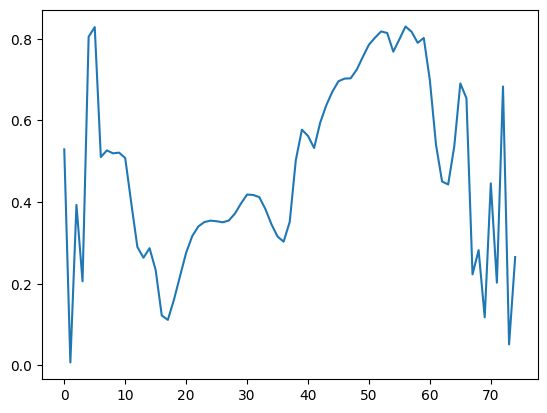

In [ ]:
plt.plot(np.abs(V_meas-V_pred2) * 1000)

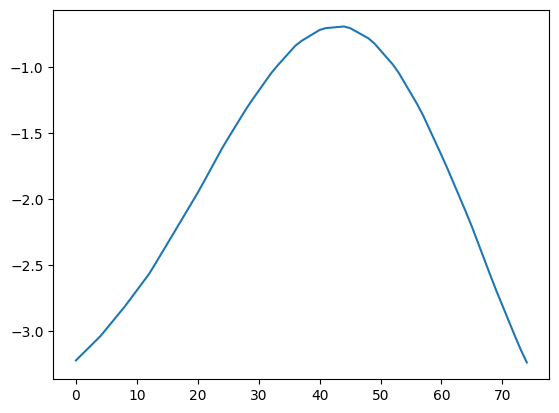

In [ ]:
plt.plot(target_current)

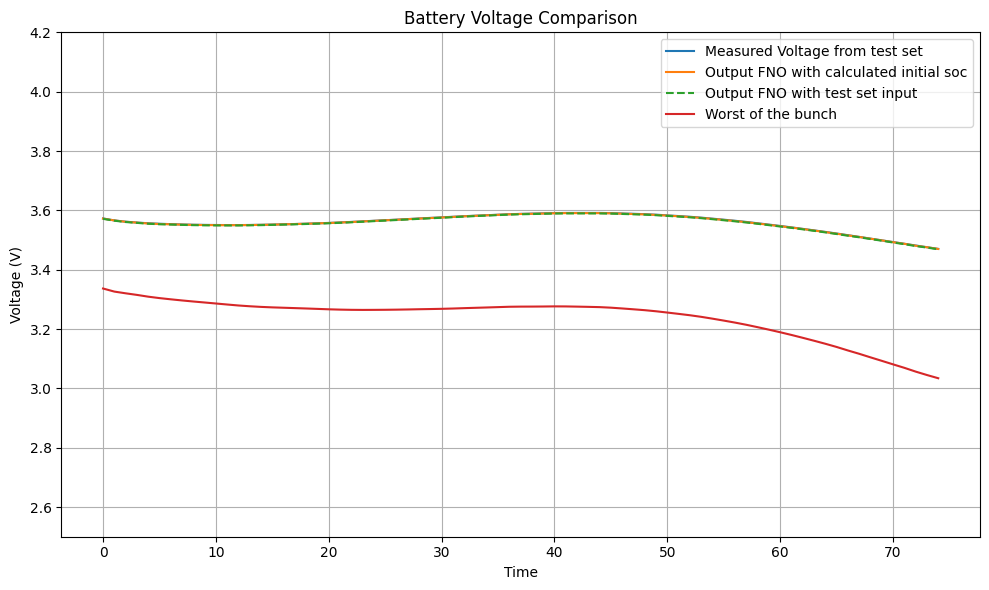

In [ ]:
# Create a figure with a larger size for clarity
plt.figure(figsize=(10, 6))

# Plot the voltage data with labels for the legend
plt.plot(V_meas, label="Measured Voltage from test set")
plt.plot(V_pred2, label="Output FNO with calculated initial soc")
plt.plot(V_pred3, linestyle = "--", label="Output FNO with test set input")
plt.plot(V_worst, label="Worst of the bunch")

# Label axes and add a title
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Battery Voltage Comparison")

# Set y-axis limits based on battery parameters from pybamm
plt.ylim(params_bat["Lower voltage cut-off [V]"], params_bat["Upper voltage cut-off [V]"])

# Add grid lines and legend
plt.grid(True)
plt.legend()

# Adjust layout for better spacing and display the plot
plt.tight_layout()
plt.show()

In [ ]:
c0_av = jnp.mean(c0_anode_sol[best_idx])
soc_from_c0_anode(c0_av)

Array(0.40116903, dtype=float32)

In [ ]:
soc_true = soc_from_c0_anode(jnp.mean(test_c0_anode[test_idx]))
soc_true

Array(0.39999995, dtype=float32)

In [ ]:
soc_cathode = soc_from_c0_cathode(jnp.mean(c0_cathode_sol[best_idx]))
soc_cathode

Array(0.40116906, dtype=float32)

In [ ]:
soc_cathode_true = soc_from_c0_cathode(jnp.mean(test_c0_cathode[test_idx]))
soc_cathode_true

Array(0.4000002, dtype=float32)

In [ ]:
spm = pybamm.lithium_ion.SPM()
sim = pybamm.Simulation(spm, parameter_values=params_bat)
sim.parameter_values["Current function [A]"] = pybamm.Interpolant(t, -1.0 * target_current, pybamm.t)
sol = sim.solve(initial_soc=0.3, t_eval=t)

In [ ]:
soc-soc_true

Array(0.6, dtype=float32)

In [ ]:
c0_av = jnp.mean(c0_anode_sol[worst_idx])
soc_from_c0_anode(c0_av) - soc_true

Array(-0.23926616, dtype=float32)

{'whiskers': [<matplotlib.lines.Line2D at 0x72fdcdc911d0>,
 'caps': [<matplotlib.lines.Line2D at 0x72fdcdc99350>,
 'boxes': [<matplotlib.lines.Line2D at 0x72fdcdc5dbd0>],
 'medians': [<matplotlib.lines.Line2D at 0x72fdcdc9b0d0>],
 'fliers': [],
 'means': []}

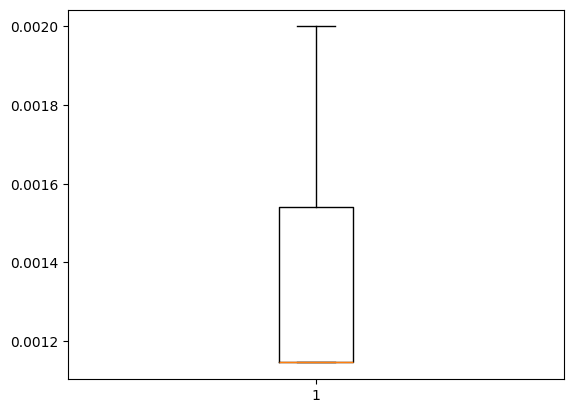

In [ ]:
plt.boxplot(loss, showfliers = False)

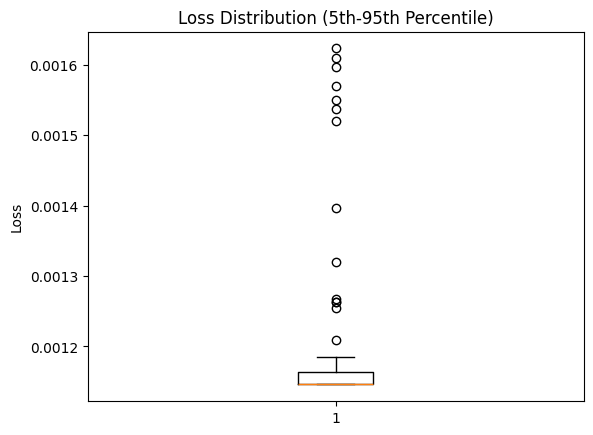

In [ ]:
loss_array_np = loss
q_low, q_high = np.percentile(loss_array_np, [5, 80])
filtered_loss = loss_array_np[(loss_array_np >= q_low) & (loss_array_np <= q_high)]

plt.boxplot(filtered_loss)
plt.title("Loss Distribution (5th-95th Percentile)")
plt.ylabel("Loss")
plt.show()


In [ ]:
loss

Array([0.00160983, 0.00114588, 0.00131979, 0.00151988, 0.00114588,
       0.00114588, 0.00126338, 0.00116931, 0.00114627, 0.00114588,
       0.00114588, 0.00114588, 0.04928447, 0.00116371, 0.00114589,
       0.00162381, 0.00116477, 0.00114586, 0.0011481 , 0.0012086 ,
       0.00249245, 0.00199955, 0.00114608, 0.00114587, 0.00126746,
       0.00114587, 0.0012632 , 0.00163232, 0.04727481, 0.00118431,
       0.0694305 , 0.10490343, 0.00162316, 0.00116521, 0.00114588,
       0.00114587, 0.03321426, 0.00385284, 0.00114586, 0.0015964 ,
       0.00117804, 0.02606621, 0.00114587, 0.00114585, 0.00114587,
       0.00114588, 0.00114588, 0.00114589, 0.00114588, 0.00114587,
       0.00114588, 0.0015506 , 0.0015696 , 0.00114588, 0.00114586,
       0.00114588, 0.00114601, 0.00114588, 0.05623655, 0.00114587,
       0.00114586, 0.00114587, 0.00115805, 0.00114586, 0.00114586,
       0.04855189, 0.00114586, 0.00114586, 0.00114586, 0.07913172,
       0.00114587, 0.00114586, 0.00114587, 0.00114587, 0.00162

In [ ]:
loss.mean()

Array(0.00842037, dtype=float32)

In [ ]:
np.savez("plots/boxplot/loss_fno.npz",loss)

In [ ]:
# key = jax.random.PRNGKey(43)  # your random seed
# # Generate a random permutation of indices, then take the first 10
# sampled_indices = jax.random.permutation(key, test_I.shape[0])[:10]
# target_currents = test_I[sampled_indices]

# for idx,target_current in zip(sampled_indices,target_currents):
#     V_meas, test_idx = get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise = 0, idx = idx)
#     learning_rate = 1e-3
#     socs_initial = sample_initial_guesses(key_sampling, batch_size=batch_size, soc = True)
#     run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
#     # c0_anode_sol, c0_cathode_sol, loss = run_batch_search(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
#     c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)

#     loss[loss.argmin()]

In [ ]:
import time
import jax
import jax.numpy as jnp

# Assumptions:
# - test_I is an array of currents with shape (8800, 75)
# - get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise, idx)
#   returns a tuple (V_meas, test_idx)
# - sample_initial_guesses(key, batch_size, soc=True) returns a SOC initial guess
#   with shape (batch_size,) (or (batch_size, ...) as required)
# - soc_search_jax_soc is your function that takes (soc_init, current, V_meas)
#   and returns (c0_anode, c0_cathode, loss), where loss is an array (one loss per sample)
# - batch_size is defined

# Set up a key and sample 10 random indices from test_I:
key = jax.random.PRNGKey(43)
sampled_indices = jax.random.permutation(key, test_I.shape[0])[:10]
target_currents = test_I[sampled_indices]

V_measures = jax.vmap(fno_predict_voltage, in_axes=(0,0,0), out_axes=0)(test_c0_anode[sampled_indices], test_c0_cathode[sampled_indices],target_currents)

num_runs = 10
run = 0
times = []
all_min_losses = []
socs_pred = []
socs_trues = soc_from_c0_anode(jnp.mean(test_c0_anode[sampled_indices],axis=1))

# Initialize a key for SOC sampling. We'll update it in each iteration.
key_sampling = jax.random.PRNGKey(100)
run_best_losses = []  # store best loss per current in this run

# Loop over the 10 sampled currents
for V_meas, target_current in zip(V_measures, target_currents):
    run = run + 1
    run_start = time.time()
    # Get the dummy measurement for the current sample.
    
    # Generate a new key for the SOC initial guesses.
    key_sampling, subkey = jax.random.split(key_sampling)
    socs_initial = sample_initial_guesses(subkey, batch_size=batch_size, soc=True)
    
    # Vectorize the SOC search function over the batch dimension.
    run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
    c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)
    
    # Accuracy metric: minimal loss across the batch.
    best_loss = loss[jnp.argmin(loss)]
    socs_pred.append(soc_from_c0_anode(jnp.mean(c0_anode_sol[jnp.argmin(loss)])))

    run_best_losses.append(best_loss)

    run_time = time.time() - run_start
    times.append(run_time)

    print(f"Run {run}: Time = {run_time:.3f} s, Best Losses = {run_best_losses}")

avg_time = sum(times) / len(times)
print("Average run time over", num_runs, "runs:", avg_time)


NameError: name 'test_I' is not defined

In [ ]:
np.savez("plots/boxplot/loss_fno_benchmark.npz",run_best_losses)